## GEO Sample Metadata — `10_GEOInfo.txt`

3,267 rows mapping GEO sample accessions (`GSM...`) to cell lines via Cellosaurus IDs. Without this file, the 3,267 sample columns in the GEO expression file cannot be attributed to specific cell lines. ~938 rows have minimal metadata (accession + CVCL only) but are still usable for joining.

In [1]:
import __init__ as ini
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 100


In [2]:
df = pd.read_csv(ini.df10, sep='\t')

In [3]:
df.head()

,Geo_accession,CEL_file_names,title,status,submission_date,last_update_date,type,channel_count,source_name_ch1,organism_ch1,...,contact_institute,GSE_ID,GSE_filename,cell_line,disease,origin,Cellosaurus_ID,Cellline,Matching_Type,cell_line_Trimmed
0,GSM101610,GSM101610,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0131,A-172,Cello GEO GSM,NaN
1,GSM101615,GSM101615,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0393,LN-229,Cello GEO GSM,NaN
2,GSM101616,GSM101616,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_0393,LN-229,Cello GEO GSM,NaN
3,GSM101667,GSM101667,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_1715,SW1088,Cello GEO GSM,NaN
4,GSM101668,GSM101668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,CVCL_1715,SW1088,Cello GEO GSM,NaN


In [4]:
df.shape

(3267, 23)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3267 entries, 0 to 3266
Data columns (total 23 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Geo_accession        3267 non-null   str    
 1   CEL_file_names       3267 non-null   str    
 2   title                2329 non-null   str    
 3   status               2329 non-null   str    
 4   submission_date      2329 non-null   str    
 5   last_update_date     2329 non-null   str    
 6   type                 2329 non-null   str    
 7   channel_count        2329 non-null   float64
 8   source_name_ch1      2329 non-null   str    
 9   organism_ch1         2329 non-null   str    
 10  characteristics_ch1  2329 non-null   str    
 11  platform_id          2329 non-null   str    
 12  contact_country      2329 non-null   str    
 13  contact_institute    2329 non-null   str    
 14  GSE_ID               2329 non-null   str    
 15  GSE_filename         2329 non-null   str    
 16 

In [6]:
df.loc[0]

Geo_accession              GSM101610
CEL_file_names             GSM101610
title                            NaN
status                           NaN
submission_date                  NaN
last_update_date                 NaN
type                             NaN
channel_count                    NaN
source_name_ch1                  NaN
organism_ch1                     NaN
characteristics_ch1              NaN
platform_id                      NaN
contact_country                  NaN
contact_institute                NaN
GSE_ID                           NaN
GSE_filename                     NaN
cell_line                        NaN
disease                          NaN
origin                           NaN
Cellosaurus_ID             CVCL_0131
Cellline                       A-172
Matching_Type          Cello GEO GSM
cell_line_Trimmed                NaN
Name: 0, dtype: object

### Missing values
Only the bottom ~2,329 rows have full metadata; the top 938 are accession-only. The chart below makes this structural gap visible.

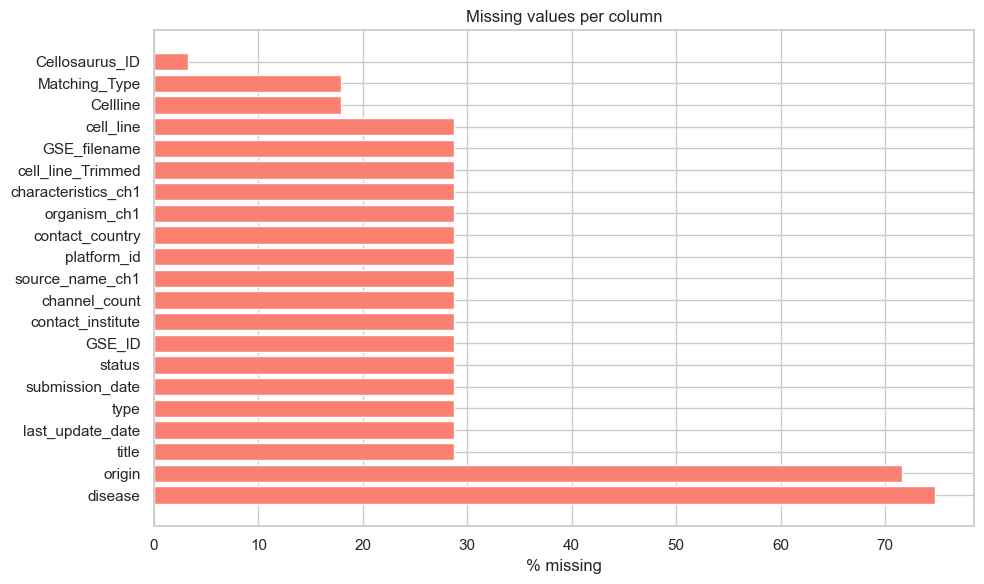

In [7]:
pct_missing = df.isnull().mean().sort_values(ascending=False) * 100
pct_missing = pct_missing[pct_missing > 0]

fig, ax = plt.subplots(figsize=(10, 6))
ax.barh(pct_missing.index, pct_missing.values, color="salmon")
ax.set_xlabel("% missing"); ax.set_title("Missing values per column")
plt.tight_layout(); plt.show()


### Cell line coverage
How many of the 3,267 GSM samples can be matched to a cell line via Cellosaurus?

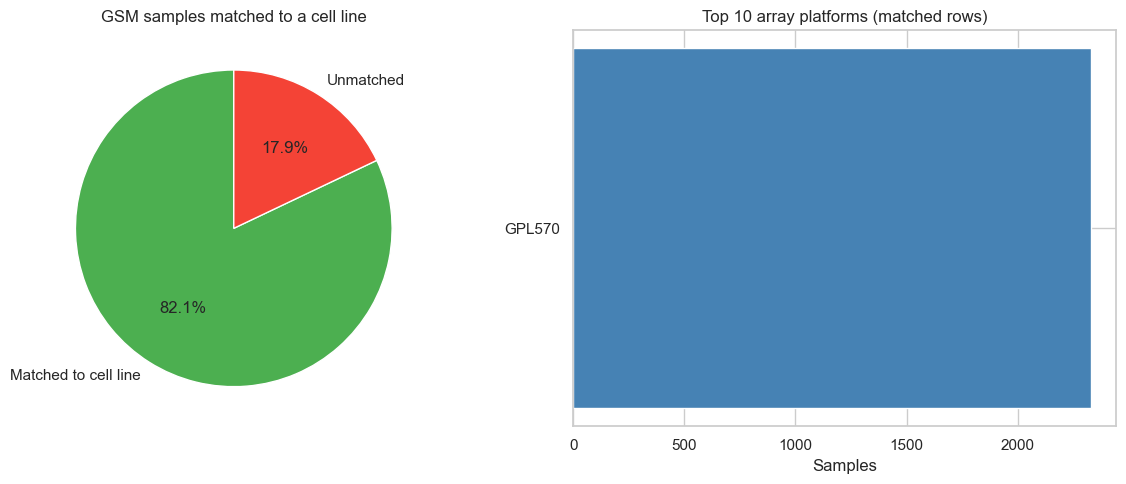

In [8]:
matched   = df["Cellline"].notna().sum()
unmatched = len(df) - matched

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie([matched, unmatched], labels=["Matched to cell line", "Unmatched"],
            autopct="%1.1f%%", startangle=90, colors=["#4CAF50", "#F44336"])
axes[0].set_title("GSM samples matched to a cell line")

# Platform distribution for matched rows
full_meta = df[df["platform_id"].notna()]
top_platforms = full_meta["platform_id"].value_counts().head(10)
axes[1].barh(top_platforms.index[::-1], top_platforms.values[::-1], color="steelblue")
axes[1].set_title("Top 10 array platforms (matched rows)")
axes[1].set_xlabel("Samples")

plt.tight_layout(); plt.show()


### Disease and tissue annotations
Only ~30% of samples have disease/origin annotations; still useful for filtered analyses.

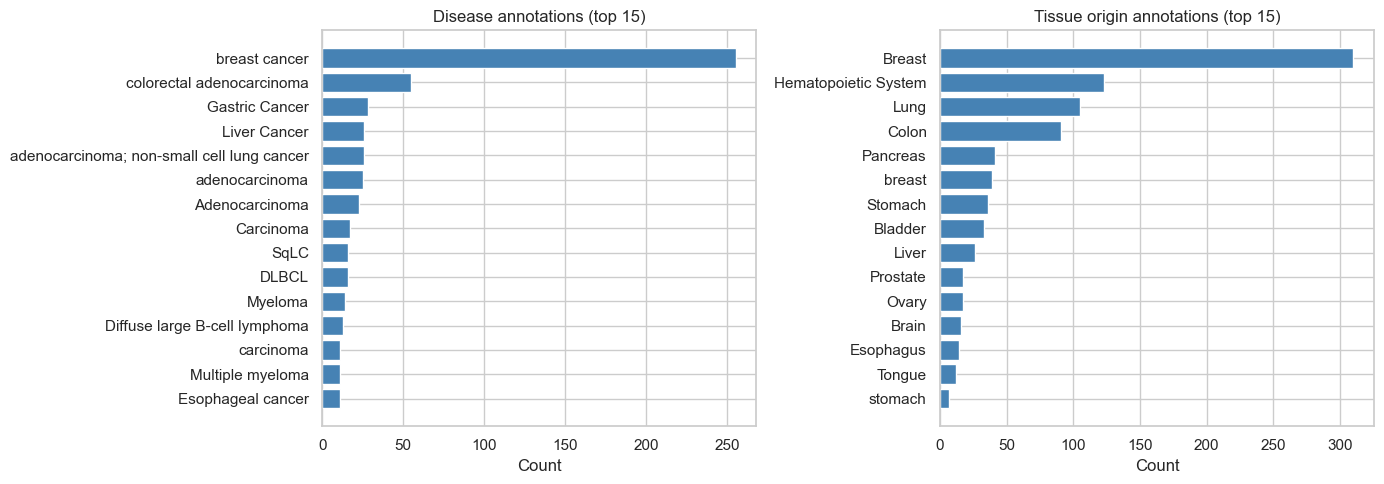

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, col, title in [
    (axes[0], "disease", "Disease annotations (top 15)"),
    (axes[1], "origin",  "Tissue origin annotations (top 15)"),
]:
    vc = df[col].value_counts().head(15)
    ax.barh(vc.index[::-1], vc.values[::-1], color="steelblue")
    ax.set_title(title); ax.set_xlabel("Count")

plt.tight_layout(); plt.show()


### Key findings

In [10]:
print("=== GEO Info ===")
print(f"Total GSM samples           : {len(df)}")
print(f"With Cellosaurus ID         : {df['Cellosaurus_ID'].notna().sum()}")
print(f"Matched to a cell line name : {df['Cellline'].notna().sum()}")
print(f"With full metadata (GSE etc): {df['title'].notna().sum()}")
print(f"Unique cell lines matched   : {df['Cellline'].nunique()}")


=== GEO Info ===
Total GSM samples           : 3267
With Cellosaurus ID         : 3159
Matched to a cell line name : 2681
With full metadata (GSE etc): 2329
Unique cell lines matched   : 886


## Join Analysis — how this table connects to the others

df10 bridges GEO sample accessions (used in df3 column headers) to Cellosaurus IDs
(used in df7 and df11). Without df10, df3's expression data is unattributed.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df10 | `Geo_accession` | df3 | column headers | 1:1 | GSM metadata |
| df10 | `Cellosaurus_ID` | df7 | `Accession (CVCL_xxxx)` | many:1 | name bridge |
| df10 | `Cellosaurus_ID` → RRID | df9 | `RRID` | many:1 | → DepMap world |

**Biological note:** df10 was built by matching GEO sample descriptions to Cellosaurus
entries. Unmatched samples (938 rows) may be primary cultures or patient biopsies —
not cell lines — and correctly cannot be attributed to a canonical cell line.


In [11]:
# ── A/B: Join coverage in both directions ────────────────────────────────────
geo_cols = pd.read_csv(ini.df3, sep="\t", nrows=0).columns
gsm_in_df3 = set(c for c in geo_cols if c.startswith("GSM"))

df7_cvcl = set(pd.read_csv(ini.df7, usecols=["Accession (CVCL_xxxx)"])
                 ["Accession (CVCL_xxxx)"].dropna())
df9_ids  = pd.read_csv(ini.df9, usecols=["DepMap_ID","RRID","lineage"])
df9_rrid = set(df9_ids["RRID"].dropna())

# Direction 1: df10 GSM → df3
df10_gsm   = set(df["Geo_accession"].dropna())
match_gsm  = df10_gsm & gsm_in_df3
only_df10  = df10_gsm - gsm_in_df3   # in df10 but not in df3 columns
only_df3   = gsm_in_df3 - df10_gsm   # GSM columns in df3 with no df10 record

# Direction 2: df10 Cellosaurus_ID → df7
df10_cvcl  = set(df["Cellosaurus_ID"].dropna())
match_cvcl = df10_cvcl & df7_cvcl
lost_cvcl  = df10_cvcl - df7_cvcl

# Direction 3: through to df9
match_rrid = match_cvcl & df9_rrid

print("=== df10 join coverage ===")
print(f"df10 GSM accessions         : {len(df10_gsm)}")
print(f"  Matched in df3 columns    : {len(match_gsm)} ({len(match_gsm)/len(df10_gsm)*100:.1f}%)")
print(f"  Only in df10 (not df3)    : {len(only_df10)}")
print(f"  Only in df3 (no metadata) : {len(only_df3)}")
print()
print(f"df10 Cellosaurus_IDs        : {len(df10_cvcl)}")
print(f"  Matched in df7            : {len(match_cvcl)} ({len(match_cvcl)/len(df10_cvcl)*100:.1f}%)")
print(f"  Not in df7                : {len(lost_cvcl)}")
print()
print(f"Reaching df9 (RRID)         : {len(match_rrid)} ({len(match_rrid)/len(df10_cvcl)*100:.1f}%)")


=== df10 join coverage ===
df10 GSM accessions         : 3267
  Matched in df3 columns    : 3267 (100.0%)
  Only in df10 (not df3)    : 0
  Only in df3 (no metadata) : 0

df10 Cellosaurus_IDs        : 797
  Matched in df7            : 797 (100.0%)
  Not in df7                : 0

Reaching df9 (RRID)         : 588 (73.8%)


In [12]:
# ── C: Format checks ─────────────────────────────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["Geo_accession"], "Geo_accession (df10)", prefix="GSM")
print()
fmt_check(df["Cellosaurus_ID"].dropna(), "Cellosaurus_ID (df10)", prefix="CVCL_")


Format check — Geo_accession (df10) (n=3267 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'GSM'  : True
  Length range        : 9 – 10
  Duplicates          : 0

Format check — Cellosaurus_ID (df10) (n=3159 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 2362


### Biological implications

GSM columns in df3 that have NO df10 record are expression samples that can never be
attributed to a cell line — they must be excluded from any cell-line-level analysis.

Cellosaurus IDs from df10 that are NOT in df7 indicate GEO samples matched to a
Cellosaurus entry that wasn't included in our df7 export (possible version mismatch
or the CVCL_ entry was added after the df7 snapshot was taken).


In [13]:
# What fraction of df3's expression data is usable after full join?
usable_samples = gsm_in_df3 & match_gsm  # GSM in df3 that df10 knows about
print(f"df3 GSM columns              : {len(gsm_in_df3)}")
print(f"Usable (in df10 with CVCL_)  : {len(usable_samples)} ({len(usable_samples)/len(gsm_in_df3)*100:.1f}%)")
print(f"Unusable (no df10 metadata)  : {len(only_df3)} ({len(only_df3)/len(gsm_in_df3)*100:.1f}%)")
print()
lineages_reached = df9_ids[df9_ids["RRID"].isin(match_rrid)]["lineage"].value_counts()
print("Lineages reachable via GEO → df10 → df9 (top 10):")
print(lineages_reached.head(10).to_string())


df3 GSM columns              : 3267
Usable (in df10 with CVCL_)  : 3267 (100.0%)
Unusable (no df10 metadata)  : 0 (0.0%)

Lineages reachable via GEO → df10 → df9 (top 10):
lineage
lung                      103
breast                     61
lymphocyte                 58
colorectal                 50
blood                      41
ovary                      37
skin                       35
pancreas                   27
gastric                    26
central_nervous_system     25


## Join Analysis — how this table connects to the others

df10 bridges GEO sample accessions (used in df3 column headers) to Cellosaurus IDs
(used in df7 and df11). Without df10, df3's expression data is unattributed.

| From | Key column | To | Key column | Cardinality | Notes |
|---|---|---|---|---|---|
| df10 | `Geo_accession` | df3 | column headers | 1:1 | GSM metadata |
| df10 | `Cellosaurus_ID` | df7 | `Accession (CVCL_xxxx)` | many:1 | name bridge |
| df10 | `Cellosaurus_ID` → RRID | df9 | `RRID` | many:1 | → DepMap world |

**Biological note:** df10 was built by matching GEO sample descriptions to Cellosaurus
entries. Unmatched samples (938 rows) may be primary cultures or patient biopsies —
not cell lines — and correctly cannot be attributed to a canonical cell line.


In [14]:
# ── A/B: Join coverage in both directions ────────────────────────────────────
geo_cols = pd.read_csv(ini.df3, sep="\t", nrows=0).columns
gsm_in_df3 = set(c for c in geo_cols if c.startswith("GSM"))

df7_cvcl = set(pd.read_csv(ini.df7, usecols=["Accession (CVCL_xxxx)"])
                 ["Accession (CVCL_xxxx)"].dropna())
df9_ids  = pd.read_csv(ini.df9, usecols=["DepMap_ID","RRID","lineage"])
df9_rrid = set(df9_ids["RRID"].dropna())

# Direction 1: df10 GSM → df3
df10_gsm   = set(df["Geo_accession"].dropna())
match_gsm  = df10_gsm & gsm_in_df3
only_df10  = df10_gsm - gsm_in_df3   # in df10 but not in df3 columns
only_df3   = gsm_in_df3 - df10_gsm   # GSM columns in df3 with no df10 record

# Direction 2: df10 Cellosaurus_ID → df7
df10_cvcl  = set(df["Cellosaurus_ID"].dropna())
match_cvcl = df10_cvcl & df7_cvcl
lost_cvcl  = df10_cvcl - df7_cvcl

# Direction 3: through to df9
match_rrid = match_cvcl & df9_rrid

print("=== df10 join coverage ===")
print(f"df10 GSM accessions         : {len(df10_gsm)}")
print(f"  Matched in df3 columns    : {len(match_gsm)} ({len(match_gsm)/len(df10_gsm)*100:.1f}%)")
print(f"  Only in df10 (not df3)    : {len(only_df10)}")
print(f"  Only in df3 (no metadata) : {len(only_df3)}")
print()
print(f"df10 Cellosaurus_IDs        : {len(df10_cvcl)}")
print(f"  Matched in df7            : {len(match_cvcl)} ({len(match_cvcl)/len(df10_cvcl)*100:.1f}%)")
print(f"  Not in df7                : {len(lost_cvcl)}")
print()
print(f"Reaching df9 (RRID)         : {len(match_rrid)} ({len(match_rrid)/len(df10_cvcl)*100:.1f}%)")


=== df10 join coverage ===
df10 GSM accessions         : 3267
  Matched in df3 columns    : 3267 (100.0%)
  Only in df10 (not df3)    : 0
  Only in df3 (no metadata) : 0

df10 Cellosaurus_IDs        : 797
  Matched in df7            : 797 (100.0%)
  Not in df7                : 0

Reaching df9 (RRID)         : 588 (73.8%)


In [15]:
# ── C: Format checks ─────────────────────────────────────────────────────────
def fmt_check(series, name, prefix=None):
    s = series.dropna().astype(str)
    print(f"Format check — {name} (n={len(s)} non-null, {series.isna().sum()} NaN):")
    print(f"  Leading whitespace  : {s.str.startswith(' ').any()}")
    print(f"  Trailing whitespace : {s.str.endswith(' ').any()}")
    if prefix:
        ok = s.str.startswith(prefix).all()
        print(f"  All start '{prefix}'  : {ok}")
        if not ok:
            print(f"  Non-prefix examples : {s[~s.str.startswith(prefix)].head(3).tolist()}")
    lens = s.str.len()
    print(f"  Length range        : {lens.min()} – {lens.max()}")
    dups = series.duplicated().sum()
    print(f"  Duplicates          : {dups}")


fmt_check(df["Geo_accession"], "Geo_accession (df10)", prefix="GSM")
print()
fmt_check(df["Cellosaurus_ID"].dropna(), "Cellosaurus_ID (df10)", prefix="CVCL_")


Format check — Geo_accession (df10) (n=3267 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'GSM'  : True
  Length range        : 9 – 10
  Duplicates          : 0

Format check — Cellosaurus_ID (df10) (n=3159 non-null, 0 NaN):
  Leading whitespace  : False
  Trailing whitespace : False
  All start 'CVCL_'  : True
  Length range        : 9 – 9
  Duplicates          : 2362


### Biological implications

GSM columns in df3 that have NO df10 record are expression samples that can never be
attributed to a cell line — they must be excluded from any cell-line-level analysis.

Cellosaurus IDs from df10 that are NOT in df7 indicate GEO samples matched to a
Cellosaurus entry that wasn't included in our df7 export (possible version mismatch
or the CVCL_ entry was added after the df7 snapshot was taken).


In [16]:
# What fraction of df3's expression data is usable after full join?
usable_samples = gsm_in_df3 & match_gsm  # GSM in df3 that df10 knows about
print(f"df3 GSM columns              : {len(gsm_in_df3)}")
print(f"Usable (in df10 with CVCL_)  : {len(usable_samples)} ({len(usable_samples)/len(gsm_in_df3)*100:.1f}%)")
print(f"Unusable (no df10 metadata)  : {len(only_df3)} ({len(only_df3)/len(gsm_in_df3)*100:.1f}%)")
print()
lineages_reached = df9_ids[df9_ids["RRID"].isin(match_rrid)]["lineage"].value_counts()
print("Lineages reachable via GEO → df10 → df9 (top 10):")
print(lineages_reached.head(10).to_string())


df3 GSM columns              : 3267
Usable (in df10 with CVCL_)  : 3267 (100.0%)
Unusable (no df10 metadata)  : 0 (0.0%)

Lineages reachable via GEO → df10 → df9 (top 10):
lineage
lung                      103
breast                     61
lymphocyte                 58
colorectal                 50
blood                      41
ovary                      37
skin                       35
pancreas                   27
gastric                    26
central_nervous_system     25


## Deeper dive: name-resolution loss at each hop

Quantify the funnel that turns raw GEO samples into DepMap-attributable cell lines:
total GSM -> has Cellosaurus ID -> that CVCL exists in the df9 catalogue.

In [17]:
import __init__ as ini
r = set(pd.read_csv(ini.df9, usecols=["RRID"])["RRID"].dropna())
n_total = len(df)
n_cvcl  = df["Cellosaurus_ID"].notna().sum()
n_in_df9 = df["Cellosaurus_ID"].isin(r).sum()
print(f"GSM samples                       : {n_total}")
print(f"  with Cellosaurus ID             : {n_cvcl} ({n_cvcl/n_total*100:.1f}%)")
print(f"  CVCL present in df9 catalogue    : {n_in_df9} ({n_in_df9/n_total*100:.1f}%)")
print("\nMatching_Type breakdown:")
print(df["Matching_Type"].value_counts(dropna=False).to_string())

GSM samples                       : 3267
  with Cellosaurus ID             : 3159 (96.7%)
  CVCL present in df9 catalogue    : 2308 (70.6%)

Matching_Type breakdown:
Matching_Type
Cello GEO GSM              1191
Cello Cell line Name        905
NaN                         586
Cello Cell line Synonym     528
Cello match alphanum         57


## In Plain English — What This Dataset Means & Where It Goes Next

### 1. What this data actually is (layman terms)
This is the **translator slip for the older GEO expression file (df3)**. That expression file labels its samples with cryptic `GSM...` codes; this file says *"sample GSM123 corresponds to cell line CVCL_456,"* so the GEO measurements can be matched to real, named cell lines and eventually to the DepMap spine.

### 2. What we found, and the next steps (preprocessing + missing EDA)
What the notebook showed:
- **3,267 GEO samples**, each (mostly) carrying a `Cellosaurus_ID` (`CVCL_`) that bridges toward the master catalogue.
- The `GSM → df3` link is **100% complete**, but only **~74% of the cell IDs reach the DepMap catalogue** — so a chunk of GEO samples can't be tied back to a known cell line.
- Many samples are unmatched because they're biopsies/primary tissue (correctly excluded, since the project is about *cell lines*).

Next steps (preprocessing):
- **Use it only if the GEO expression file (df3) is kept.** Bridge `Geo_accession → Cellosaurus_ID → DepMap_ID`.
- No feature extraction — it's purely a connector.

Still missing in EDA: nothing — it's plumbing for df3, and its coverage limits are already quantified.

### 3. Which ML approach fits this dataset
**Neither — this is not a model input.** It's an **ID-mapping table** whose only purpose is translating GEO sample codes into real cell lines. It's needed only to the extent the GEO expression file is used.

> **Big-picture note:** Like the other bridge files, it exists to route data onto the DepMap spine; given df3's heavy join loss, this connector may end up barely used.